In [318]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [319]:
import numpy as np
import scipy
import matplotlib
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors

In [320]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [321]:
def compute_P_levels(p0, ps):
    # Compute the p levels in a hybrid model.
    # Hard code the coefficients here:
    lev = 56
    ilev = 57

    hyai = np.array([0.09050670980690104, 0.08995635981437577, 0.08937238067306334, 0.08875271747306365, 0.08809518973916056, 0.08739748375815026, 0.08665714443733119, 0.08587156666550647, 0.08503798614610039, 0.08415346967013226, 0.08321490479482004, 0.08221898889149477, 0.08116221752428777, 0.08004087211869704, 0.07885100687664118, 0.07758843489195744, 0.07624871341748701, 0.07482712823190504, 0.07331867705128559, 0.0717180519270299, 0.07001962056821956, 0.06821740652267175, 0.0663050681469573, 0.06427587629138137, 0.06212269062140435, 0.05983793449218211, 0.05741356828781585, 0.05484106113149445, 0.05211136086698559, 0.04921486220584492, 0.04614137292825965, 0.04288007801859395, 0.039478344424962786, 0.036295676722387205, 0.03332940558992792, 0.030573339223869955, 0.02801882331670602, 0.025655591039917103, 0.02347242775851588, 0.021457678362589494, 0.019599624710769814, 0.017886758358974353, 0.016307970549427342, 0.014852678008666409, 0.013510899819456301, 0.012273297678638384, 0.011131189305746858, 0.010076542633771557, 0.009009311071453197, 0.007929344445782083, 0.0068364907917635165, 0.005730596331034787, 0.00461150545022615, 0.0034790606790643386, 0.002333102668214404, 0.0011734701668573155, 0.0])
    hybi = np.array([0.0, 0.006080764549937297, 0.012533094355742546, 0.019379693920810688, 0.026644655107732278, 0.03435354191290797, 0.04253348042131927, 0.051213254257985986, 0.06042340587198839, 0.07019634400945093, 0.0805664577536661, 0.09157023753364128, 0.10324640352687701, 0.11563604190819884, 0.12878274942407789, 0.14273278680116816, 0.15753524152887585, 0.17324220058876183, 0.18990893373857776, 0.20759408799587725, 0.22635989400555315, 0.2462723850174671, 0.2674016292447125, 0.2898219764201347, 0.3136123194186923, 0.3388563718662595, 0.3656429627117196, 0.39406634879889413, 0.4242265465381863, 0.45622968384502727, 0.49018837358353046, 0.5262221098294266, 0.5638075396930111, 0.5989725314308167, 0.631746578115178, 0.6621980923944852, 0.6904226948865437, 0.716533822799943, 0.7406553855664949, 0.76291615938343, 0.7834456168765139, 0.8023709137462146, 0.8198147895971367, 0.8358941780078512, 0.8507193571804534, 0.8643935051354327, 0.8770125515611428, 0.8886652419995137, 0.9004569816903645, 0.9123894298809492, 0.924464265617992, 0.9366831879839495, 0.9490479163360934, 0.9615601905484469, 0.9742217712566049, 0.9870344401054797, 1.0])
    
    hyam = np.array([0.0902315348106384, 0.08966437024371957, 0.08906254907306349, 0.0884239536061121, 0.08774633674865541, 0.08702731409774073, 0.08626435555141883, 0.08545477640580343, 0.08459572790811633, 0.08368418723247614, 0.0827169468431574, 0.08169060320789127, 0.0806015448214924, 0.07944593949766911, 0.0782197208842993, 0.07691857415472222, 0.07553792082469603, 0.07407290264159531, 0.07251836448915774, 0.07086883624762473, 0.06911851354544565, 0.06726123733481452, 0.06529047221916934, 0.06319928345639286, 0.06098031255679323, 0.05862575138999898, 0.05612731470965515, 0.05347621099924002, 0.050663111536415256, 0.047678117567052286, 0.0445107254734268, 0.04117921122177837, 0.037887010573674995, 0.03481254115615756, 0.03195137240689894, 0.029296081270287988, 0.026837207178311562, 0.02456400939921649, 0.022465053060552687, 0.020528651536679654, 0.018743191534872083, 0.017097364454200847, 0.015580324279046875, 0.014181788914061355, 0.012892098749047343, 0.011702243492192621, 0.010603865969759207, 0.009542926852612377, 0.00846932775861764, 0.0073829176187728, 0.006283543561399152, 0.005171050890630469, 0.004045283064645244, 0.0029060816736393713, 0.0017532864175358598, 0.0005867350834286578])
    hybm = np.array([0.0030403822749686484, 0.009306929452839922, 0.015956394138276618, 0.023012174514271483, 0.030499098510320125, 0.03844351116711362, 0.046873367339652625, 0.05581833006498719, 0.06530987494071966, 0.07538140088155851, 0.08606834764365369, 0.09740832053025915, 0.10944122271753792, 0.12220939566613837, 0.13575776811262302, 0.150134014165022, 0.16538872105881885, 0.1815755671636698, 0.1987515108672275, 0.2169769910007152, 0.23631613951151012, 0.2568370071310898, 0.2786118028324236, 0.3017171479194135, 0.3262343456424759, 0.35224966728898954, 0.37985465575530686, 0.40914644766854025, 0.44022811519160676, 0.47320902871427883, 0.5082052417064785, 0.5450148247612189, 0.5813900355619139, 0.6153595547729973, 0.6469723352548316, 0.6763103936405145, 0.7034782588432433, 0.728594604183219, 0.7517857724749625, 0.773180888129972, 0.7929082653113643, 0.8110928516716757, 0.8278544838024939, 0.8433067675941524, 0.8575564311579431, 0.8707030283482877, 0.8828388967803282, 0.894561111844939, 0.9064232057856568, 0.9184268477494706, 0.9305737268009707, 0.9428655521600214, 0.9553040534422701, 0.9678909809025259, 0.9806281056810423, 0.9935172200527398])

    p_vals = np.zeros((ilev,len(ps)))

    for k in np.arange(ilev):
        #p_vals[int((ilev-k)%ilev),:] = hyai[k]*p0 + hybi[k]*ps
        p_vals[k,:] = hyai[k]*p0 + hybi[k]*ps
                      
    return p_vals

In [322]:
rot = False
u = 10

#dycore = 'fv3'
dycore = 'se'
#dycore = 'fv'

#res = 'ne30'
res = 'ne60'

if rot:
    lev_no1 = 'ztop20km_L57_new_RF'
    lev_no2 = 'ztop20km_L57_new_RF'
    lev_no3 = 'ztop20km_L57_new_RF'
    lev_no4 = 'ztop20km_L57'
    
    extra_name1 = 'tau_200s'
    extra_name2 = 'tau_100s'
    extra_name3 = 'tau_40s'
    extra_name4 = 'tau_1_10'
else:
    lev_no1 = 'ztop20km_L57'
    lev_no2 = 'ztop20km_L57_new_RF'
    lev_no3 = 'ztop20km_L57_new_RF'
    lev_no4 = 'ztop20km_L57'
    extra_name1 = 'tau_0'
    extra_name2 = 'tau_100s'
    extra_name3 = 'tau_40s'
    extra_name4 = 'tau_1_10'

CAM_branch = 'CAM_6_4_100_11082025'

test_name_start = 'cam_6_4_100'

case1 = f'{test_name_start}_{dycore}_{res}_{lev_no1}'
case2 = f'{test_name_start}_{dycore}_{res}_{lev_no2}'
case3 = f'{test_name_start}_{dycore}_{res}_{lev_no3}'
case4 = f'{test_name_start}_{dycore}_{res}_{lev_no4}'


# Compare three files
if rot:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name3}'
    nc_file4 = f'{case4}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name4}'
else:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name3}'
    nc_file4 = f'{case4}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name4}'

if dycore ==  'fv3':
    nc_file1 = f'{nc_file1}.regrid.1x1'

nc_file1 = nc_file1 + '.nc'
nc_file2 = nc_file2 + '.nc'
nc_file3 = nc_file3 + '.nc'
nc_file4 = nc_file4 + '.nc'

In [323]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2
run_path3 = run_base + case3 + '/run/' + nc_file3
run_path4 = run_base + case4 + '/run/' + nc_file4

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)
nc3 = Dataset(run_path3)
nc4 = Dataset(run_path4)

In [324]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 
lev = nc1['lev'][:]

print(lev[0])
print(lev[-1])

96.0171834859196
994.1039551361686


In [325]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat
if rot == True:
    lat_crop_up = 40.
    lat_cent_down = -40.
    lat_ticks = np.linspace(-40.,40.,5)
    
    lon_crop_left = 140.
    lon_crop_right = 280.
    lon_ticks = np.linspace(140, 280, 8)
else:
    lat_crop_up = 50.
    lat_cent_down = -50.
    lat_ticks = np.linspace(-40,40,5)

    lon_crop_left = 160.
    lon_crop_right = 280.
    lon_ticks = np.linspace(160, 280, 7)

lon_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))[0]
lat_inds = np.where((lat < lat_crop_up) & (lat > lat_cent_down))[0]

lat = lat[lat_inds]
lon = lon[lon_inds]

LON, LAT = np.meshgrid(lon, lat)

In [326]:
# Field to compare
field = 'T'

# Time index to compare at
t_idx = 40

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

# Choice of colormap
# Choice of colormap
if field == 'T':        
    cmap_choice = 'jet'
else:
    cmap_choice = 'seismic'

In [327]:
# Interpolations:
field_vals1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals4 = z_interp(nc4['Z3'][t_idx, :, lat_inds, lon_inds], nc4[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)

In [328]:
deg2rad = np.pi/180
T0 = 288

if field == 'U':
    # Normalised velocity perturbation:
        field_vals1 = (field_vals1 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals2 = (field_vals2 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals3 = (field_vals3 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals4 = (field_vals4 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
else:
    # Temperature perturbation:
        field_vals1 = field_vals1 - T0
        field_vals2 = field_vals2 - T0
        field_vals3 = field_vals3 - T0
        field_vals4 = field_vals4 - T0

min value is -1.9147496003545257
max value is 9.117400496373989


Text(0.5, 0.01, 'Longitude (deg)')

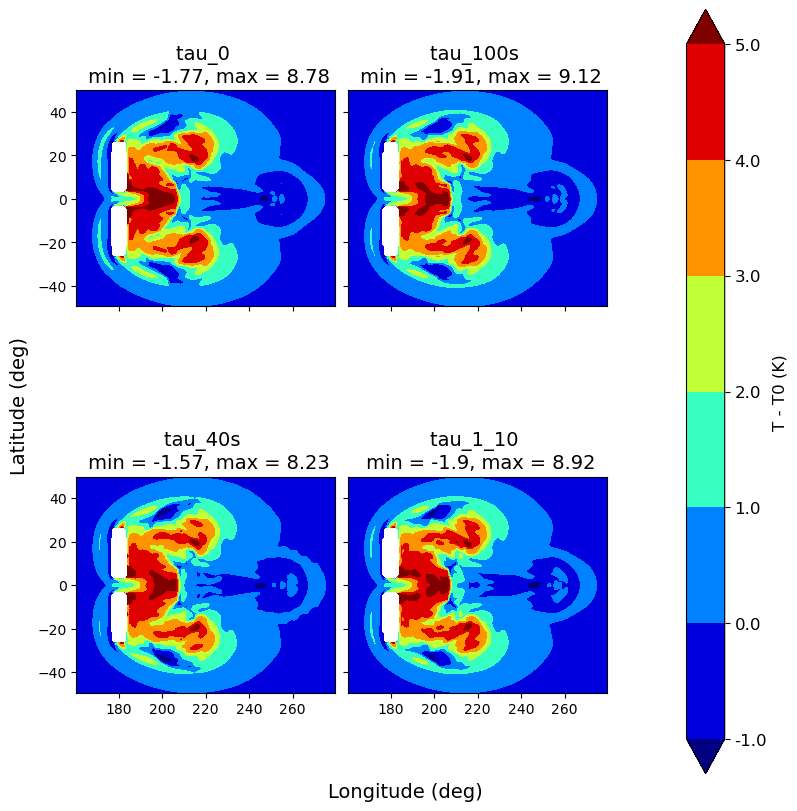

In [329]:
title_size=16
label_size=14
small_size=12

max1 = np.nanmax(field_vals1)
max2 = np.nanmax(field_vals2)
max3 = np.nanmax(field_vals3)
max4 = np.nanmax(field_vals4)

min1 = np.nanmin(field_vals1)
min2 = np.nanmin(field_vals2)
min3 = np.nanmin(field_vals3)
min4 = np.nanmin(field_vals4)

maxmax = max(max1, max2, max3, max4)
minmin = min(min1, min2, min3, min4)

print('min value is', minmin)
print('max value is', maxmax)

conts = np.linspace(minmin, maxmax, 21)

fig, axes = plt.subplots(2,2, sharex=True, sharey=True, figsize=(8,8), layout="constrained")
(ax1, ax2), (ax3, ax4) = axes

if field == 'T':
    if rot:
        conts = np.linspace(-1, 5, 7)
        norm = colors.Normalize(vmin=-1, vmax=5)
        tick_range = np.linspace(-1, 5, 7)
    else:
        conts = np.linspace(-1, 5, 7)
        norm = colors.Normalize(vmin=-1, vmax=5)
        tick_range = np.linspace(-1, 5, 7)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot4 = ax4.contourf(LON, LAT, field_vals4, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Temperature perturbation'
    cb_label = 'T - T0 (K)'
else:
    if rot:
        conts = np.linspace(-2.0, 2.0, 9)
        tick_range = np.linspace(-2.0, 2.0, 9)
        norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
    else:
        conts = np.linspace(-1.5, 1.0, 11)
        tick_range = np.linspace(-1.5, 1.0, 6)
        norm = colors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.0)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot4 = ax4.contourf(LON, LAT, field_vals4, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Normalised velocity perturbation'
    cb_label = '$(u(t) - u_0)/u_0$'

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')
ax4.set_aspect('equal')

cb = plt.colorbar(plot4,ax=axes,pad=0.15,shrink=1,format='%.1f')
cb.set_label(label=cb_label, size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{extra_name1} \n min = {np.round(min1,2)}, max = {np.round(max1,2)}', size=label_size)
ax2.set_title(f'{extra_name2} \n min = {np.round(min2,2)}, max = {np.round(max2,2)}', size=label_size)
ax3.set_title(f'{extra_name3} \n min = {np.round(min3,2)}, max = {np.round(max3,2)}', size=label_size)
ax4.set_title(f'{extra_name4} \n min = {np.round(min4,2)}, max = {np.round(max4,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

90.50670623779297


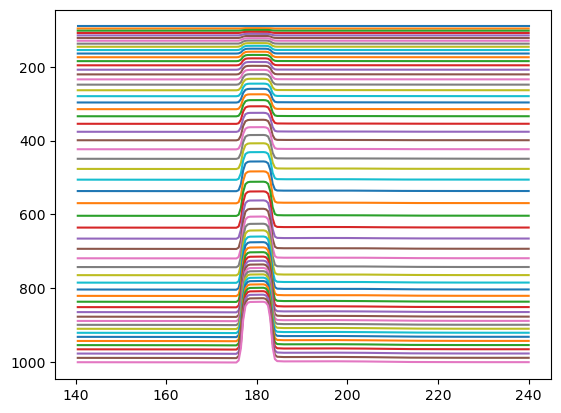

In [330]:
# Make the pressure levels and plot them to check

#P_layers = compute_P_levels(1000, 1000*np.ones_like(ps_t))
P_layers = compute_P_levels(1000, ps_t)

fig, ax = plt.subplots(1,1)
for i in np.arange(57):
    plt.plot(lon_crop, P_layers[i,:])

ax.invert_yaxis()

print(np.min(P_layers))

In [331]:
# Plot vertical cross sections to examine the damping/reflection of the gravity waves.
lon = nc1['lon'][:] 
lat = nc1['lat'][:] 
lon_crop_left = 140
lon_crop_right = 240
lon_ticks = np.linspace(140,240,6)
print(lon_ticks)

# User parameters:
t_idx = -1
field = 'W'

lon_crop_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))
lon_crop = lon[lon_crop_inds]

LONGC, P = np.meshgrid(lon_crop, lev) 

# Pick the latitude to slice at:
#lat_val = 95  # 1 degree
#lat_val=190
lat_val = 200  # 0.5-degree

lat_val_deg = np.round(lat[lat_val],0)
print('lat in deg is', lat_val_deg)

# Compute W = -omega*R_d*T0/(g*p)

if field=='W':
    Rd = 287.04
    g = 9.80616
    # Convert P from hPa to Pa
    P_Pa = P_layers*100
    field1 = -(Rd/g)*nc1['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc1['T'][t_idx, :, lat_val, lon_crop_inds[0]]/P_Pa
    field2 = -(Rd/g)*nc2['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc2['T'][t_idx, :, lat_val, lon_crop_inds[0]]/P_Pa
    field3 = -(Rd/g)*nc3['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc3['T'][t_idx, :, lat_val, lon_crop_inds[0]]/P_Pa
    field4 = -(Rd/g)*nc4['OMEGA'][t_idx, :, lat_val, lon_crop_inds[0]]*nc4['T'][t_idx, :, lat_val, lon_crop_inds[0]]/P_Pa
else:
    field1 = nc1[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field2 = nc2[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field3 = nc3[field][t_idx, :, lat_val, lon_crop_inds[0]]
    field4 = nc4[field][t_idx, :, lat_val, lon_crop_inds[0]]

ps_t = nc1['PS'][t_idx, lat_val, lon_crop_inds[0]]/100

cmap_choice = 'coolwarm'

[140. 160. 180. 200. 220. 240.]
lat in deg is 10.0


min value is -4.002455388617676
max value is 1.5784841092498483


Text(0.5, 0.98, 'W at t=0.5 days')

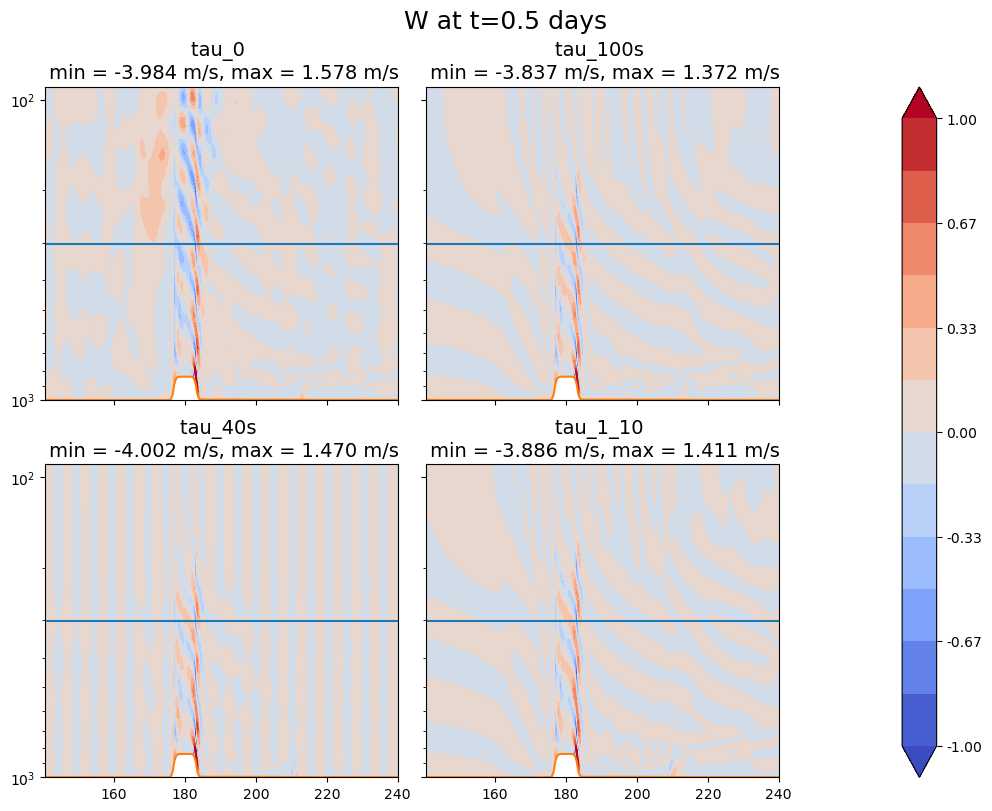

In [332]:

max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)
max4 = np.nanmax(field4)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)
min4 = np.nanmin(field4)

maxmax = max(max1, max2, max3, max4)
minmin = min(min1, min2, min3, min4)

print('min value is', minmin)
print('max value is', maxmax)

conts = np.linspace(minmin, maxmax, 21)

fig, axes = plt.subplots(2,2,figsize = (10,8), sharey=True, sharex=True, constrained_layout=True)
(ax1, ax2), (ax3, ax4) = axes

if field == 'T':
    minmin = -1
    maxmax = 1
    absmax = max(abs(minmin), abs(maxmax))
    norm = colors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
    conts = np.linspace(minmin, maxmax,13)
    tick_range = np.linspace(minmin, maxmax,13)
    plot1 = ax1.contourf(LONGC, P, field1, levels = conts, cmap=cmap_choice)
    plot2 = ax2.contourf(LONGC, P, field2, levels = conts, cmap=cmap_choice)
    plot3 = ax3.contourf(LONGC, P, field3, levels = conts, cmap=cmap_choice)
    plot4 = ax4.contourf(LONGC, P, field4, levels = conts, cmap=cmap_choice)

    title = 'Temperature perturbation'
    cb_label = 'T - T0 (K)'
    unit = 'K'
if field == 'OMEGA':
    minmin = -1
    maxmax = 1
    absmax = max(abs(minmin), abs(maxmax))
    norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
    conts = np.linspace(minmin, maxmax, 13)
    tick_range = np.linspace(minmin, maxmax, 5)
    plot1 = ax1.contourf(LONGC, P, field1, levels = conts, cmap=cmap_choice)
    plot2 = ax2.contourf(LONGC, P, field2, levels = conts, cmap=cmap_choice)
    plot3 = ax3.contourf(LONGC, P, field3, levels = conts, cmap=cmap_choice)
    plot4 = ax4.contourf(LONGC, P, field4, levels = conts, cmap=cmap_choice)
    title = 'OMEGA'
    cb_label = 'Pa/s'
    unit = 'Pa/s'
if field == 'W':
    minmin = -1
    maxmax = 1
    absmax = max(abs(minmin), abs(maxmax))
    norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
    conts = np.linspace(minmin, maxmax, 13)
    tick_range = np.linspace(minmin, maxmax, 5)
    plot1 = ax1.contourf(LONGC, P_layers, field1, levels = conts, cmap=cmap_choice, extend='both')
    plot2 = ax2.contourf(LONGC, P_layers, field2, levels = conts, cmap=cmap_choice, extend='both')
    plot3 = ax3.contourf(LONGC, P_layers, field3, levels = conts, cmap=cmap_choice, extend='both')
    plot4 = ax4.contourf(LONGC, P_layers, field4, levels = conts, cmap=cmap_choice, extend='both')
    title = 'W'
    cb_label = 'm/s'
    unit = 'm/s'
else:
    if minmin < 0:
        norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
    else:
        norm = colors.TwoSlopeNorm(vmin=-maxmax, vcenter=0, vmax=maxmax)
    plot1 = ax1.contourf(LONGC1, P1, field1, levels = conts, cmap=cmap_choice, norm=norm)
    plot2 = ax2.contourf(LONGC1, P1, field2, levels = conts, cmap=cmap_choice, norm=norm)
    plot3 = ax3.contourf(LONGC1, P1, field3, levels = conts, cmap=cmap_choice, norm=norm)

cb = plt.colorbar(plot4,ax=axes,pad=0.15,shrink=1,format='%.2f')

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')
ax4.set_yscale('log')

ax1.invert_yaxis()

# Plot the sponge layer start:
pc = 301.82

ax1.plot(lon_crop, pc*np.ones_like(lon_crop))
ax2.plot(lon_crop, pc*np.ones_like(lon_crop))
ax3.plot(lon_crop, pc*np.ones_like(lon_crop))
ax4.plot(lon_crop, pc*np.ones_like(lon_crop))

# Add the surface topography:
ax1.plot(lon_crop, ps_t)
ax2.plot(lon_crop, ps_t)
ax3.plot(lon_crop, ps_t)
ax4.plot(lon_crop, ps_t)

ax1.set_title(f'{extra_name1} \n min = {min1:.3f} m/s, max = {max1:.3f} m/s', size=label_size)
ax2.set_title(f'{extra_name2} \n min = {min2:.3f} m/s, max = {max2:.3f} m/s', size=label_size)
ax3.set_title(f'{extra_name3} \n min = {min3:.3f} m/s, max = {max3:.3f} m/s', size=label_size)
ax4.set_title(f'{extra_name4} \n min = {min4:.3f} m/s, max = {max4:.3f} m/s', size=label_size)

plt.suptitle(f'{field} at t={time[t_idx]} days',size=18)

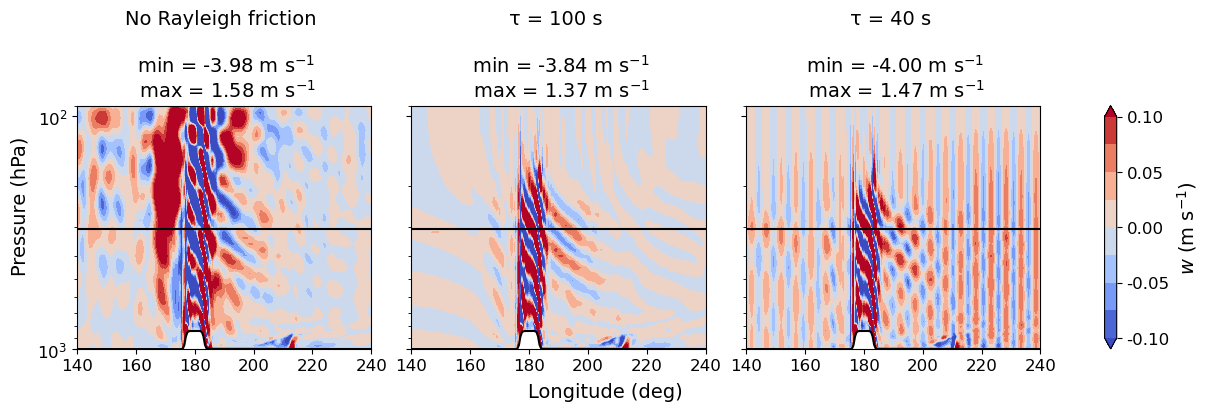

In [333]:
# Make a three by three plot. For putting in the paper.
# comparing no RF, chosen tau, and tau too large

max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)

fig, axes = plt.subplots(1,3,figsize = (12,4), sharey=True, sharex=True, constrained_layout=True)
(ax1, ax2, ax3) = axes

minmin = -0.1
maxmax = 0.1
absmax = max(abs(minmin), abs(maxmax))
norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
conts = np.linspace(minmin, maxmax, 9)
tick_range = np.linspace(minmin, maxmax, 5)


plot1 = ax1.contourf(LONGC, P_layers, field1, levels = conts, cmap=cmap_choice, extend='both')
plot2 = ax2.contourf(LONGC, P_layers, field2, levels = conts, cmap=cmap_choice, extend='both')
plot3 = ax3.contourf(LONGC, P_layers, field3, levels = conts, cmap=cmap_choice, extend='both')
title = 'W'

cb = plt.colorbar(plot3,ax=axes,pad=0.05,shrink=1,format='%.2f', ticks = tick_range)
cb.ax.tick_params(labelsize=12)
cb.set_label(r'$w$ (m s$^{-1}$)', size=14)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

ax1.set_ylim(lev[0],lev[-1])

ax1.set_yticks([1000,100])

fig.supylabel('Pressure (hPa)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

ax1.invert_yaxis()

if rot:
    ax1.set_ylim([1060,90])
else:
    ax1.set_ylim([1000,90])

# Plot the sponge layer start:
#pc = 301.82
pc = 305

ax1.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax3.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')

# Add the surface topography:
ax1.plot(lon_crop, ps_t, c='k')
ax2.plot(lon_crop, ps_t, c='k')
ax3.plot(lon_crop, ps_t, c='k')

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax3.tick_params(axis='both', which='major', labelsize=12)

plt.xticks(lon_ticks)

ax1.set_title(f'No Rayleigh friction \n \n min = {min1:.2f} ' r"m s$^{-1}$" f' \n max = {max1:.2f}' r" m s$^{-1}$", size=label_size)
#ax1.set_title(f'\u03C4 = 200 s \n \n min = {min1:.2f} m/s \n max = {max1:.2f} m/s', size=label_size)
ax2.set_title(f'\u03C4 = 100 s \n \n min = {min2:.2f} ' r"m s$^{-1}$" f' \n max = {max2:.2f}' r" m s$^{-1}$", size=label_size)
ax3.set_title(f'\u03C4 = 40 s \n \n min = {min3:.2f} ' r"m s$^{-1}$" f' \n max = {max3:.2f}' r" m s$^{-1}$", size=label_size)

savefig = False

if savefig:
    plt.savefig('figures/gap_se_rf_diff_tau_lat_10_N.png')


[140.5 141.  141.5 ... 239.  239.5 240. ]
[[  90.50670624   90.50670624   90.50670624 ...   90.50670624
    90.50670624   90.50670624]
 [  96.04277039   96.04277039   96.04276276 ...   96.04177856
    96.04177094   96.04175568]
 [ 101.91711426  101.91711426  101.917099   ...  101.91506958
   101.91505432  101.91501617]
 ...
 [ 977.45941162  977.45947266  977.45855713 ...  977.30072021
   977.2991333   977.29644775]
 [ 989.12432861  989.12438965  989.12341309 ...  988.96356201
   988.96191406  988.95922852]
 [1000.9284668  1000.92852783 1000.92755127 ... 1000.76556396
  1000.76391602 1000.76116943]]
(57, 200)
(57, 200)
(57, 200)


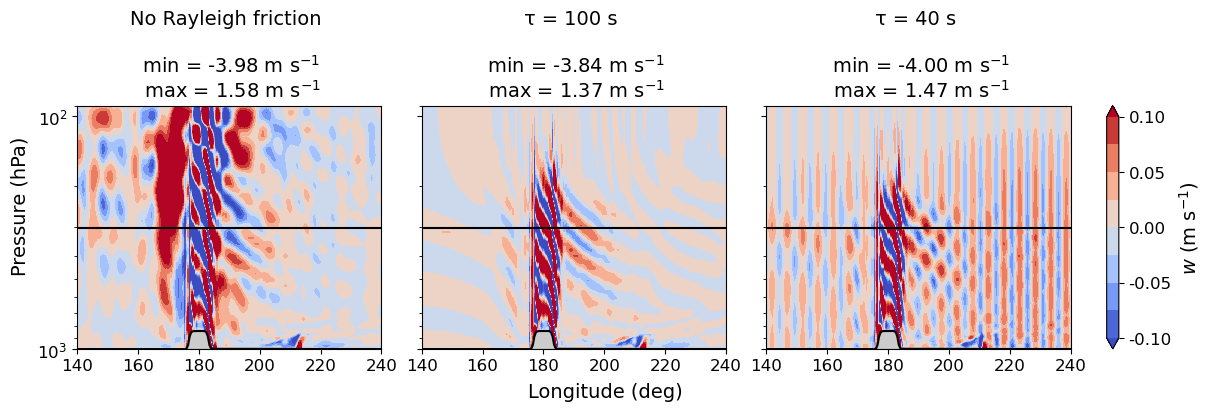

In [335]:
# Make a three by three plot. For putting in the paper.
# comparing no RF, chosen tau, and tau too large
# Here, construct the correct p values.
# Assume we have remapped to the reference levels.

# Write a script to compute the p midpoint levels.
P_layers = compute_P_levels(1000, ps_t)
P_1d = P_layers.reshape(-1)

LONGC_tri = np.tile(lon_crop, (len(lev), 1))

print(LONGC_tri.reshape(-1))
print(P_layers)

max1 = np.nanmax(field1)
max2 = np.nanmax(field2)
max3 = np.nanmax(field3)

min1 = np.nanmin(field1)
min2 = np.nanmin(field2)
min3 = np.nanmin(field3)

fig, axes = plt.subplots(1,3,figsize = (12,4), sharey=True, sharex=True, constrained_layout=True)
(ax1, ax2, ax3) = axes

minmin = -0.1
maxmax = 0.1
absmax = max(abs(minmin), abs(maxmax))
norm = colors.TwoSlopeNorm(vmin=minmin, vcenter=0, vmax=maxmax)
conts = np.linspace(minmin, maxmax, 9)
tick_range = np.linspace(minmin, maxmax, 5)

print(np.shape(LONGC_tri))
print(np.shape(P_layers))
print(np.shape(field1))

tri = matplotlib.tri.Triangulation(LONGC_tri.reshape(-1), P_layers.reshape(-1))

# No, this make it look really zig zaggy!
#plot1 = ax1.tricontourf(LONGC_tri.reshape(-1), P_layers.reshape(-1), field1.reshape(-1), levels = conts, cmap=cmap_choice, extend='both')
#plot2 = ax2.tricontourf(LONGC_tri.reshape(-1), P_layers.reshape(-1), field2.reshape(-1), levels = conts, cmap=cmap_choice, extend='both')
#plot3 = ax3.tricontourf(LONGC_tri.reshape(-1), P_layers.reshape(-1), field4.reshape(-1), levels = conts, cmap=cmap_choice, extend='both')


plot1 = ax1.contourf(LONGC, P_layers, field1, levels = conts, cmap=cmap_choice, extend='both')
plot2 = ax2.contourf(LONGC, P_layers, field2, levels = conts, cmap=cmap_choice, extend='both')
plot3 = ax3.contourf(LONGC, P_layers, field3, levels = conts, cmap=cmap_choice, extend='both')
title = 'W'
cb_label = 'm/s'
unit = 'm/s'

cb = plt.colorbar(plot3,ax=axes,pad=0.02,shrink=1,format='%.2f', ticks = tick_range)
cb.ax.tick_params(labelsize=12)
cb.set_label('$w$ (m s$^{-1}$)', size=14)

ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

fig.supylabel('Pressure (hPa)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)

# Plot the sponge layer start:
pc = 301.82

ax1.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax2.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')
ax3.plot(lon_crop, pc*np.ones_like(lon_crop), c='k')


# Add the surface topography:
ax1.plot(lon_crop, ps_t, c='k')
ax2.plot(lon_crop, ps_t, c='k')
ax3.plot(lon_crop, ps_t, c='k')

if rot:
    ax1.fill_between(lon_crop, ps_t, 1060, color='grey', alpha=0.4)
    ax2.fill_between(lon_crop, ps_t, 1060, color='grey', alpha=0.4)
    ax3.fill_between(lon_crop, ps_t, 1060, color='grey', alpha=0.4)
    plt.ylim([90,1060])
else:
    ax1.fill_between(lon_crop, ps_t, 1000, color='grey', alpha=0.4)
    ax2.fill_between(lon_crop, ps_t, 1000, color='grey', alpha=0.4)
    ax3.fill_between(lon_crop, ps_t, 1000, color='grey', alpha=0.4)
    plt.ylim([90,1000])

ax1.invert_yaxis()

ax1.tick_params(axis='both', which='major', labelsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax3.tick_params(axis='both', which='major', labelsize=12)

plt.xticks(lon_ticks)

ax1.set_title(f'No Rayleigh friction \n \n min = {min1:.2f} ' r"m s$^{-1}$" f' \n max = {max1:.2f}' r" m s$^{-1}$", size=label_size)
#ax1.set_title(f'\u03C4 = 200 s \n \n min = {min1:.2f} ' r"m s$^{-1}$" f' \n max = {max1:.2f}' r" m s$^{-1}$", size=label_size)
ax2.set_title(f'\u03C4 = 100 s \n \n min = {min2:.2f} ' r"m s$^{-1}$" f' \n max = {max2:.2f}' r" m s$^{-1}$", size=label_size)
ax3.set_title(f'\u03C4 = 40 s \n \n min = {min3:.2f} ' r"m s$^{-1}$" f' \n max = {max3:.2f}' r" m s$^{-1}$", size=label_size)

savefig = True

if savefig:
    plt.savefig('figures/gap_se_rf_diff_tau_lat_10_N.png')